In [25]:
#imported essential libraries
import numpy as np
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#reading the Dataset
df = pd.read_csv('GlobalWeatherRepository.csv')
df1 = df[['country','location_name', 'last_updated', 'temperature_celsius', 'condition_text',
         'wind_kph', 'latitude', 'humidity', 'cloud', 'sunrise', 'sunset', 'visibility_km']]
df1

In [27]:
#Renaming The Columns and Extracting new columns
df2 = df1.rename(columns = {'condition_text': 'Weather_condition'})
df2['last_updated'] = pd.to_datetime(df2['last_updated'])
df2['hour']  = df2['last_updated'].dt.hour
df2['day']   = df2['last_updated'].dt.day
df2['month'] = df2['last_updated'].dt.month
df2['min'] = df2['last_updated'].dt.minute
df3 = df2.drop(['last_updated'], axis = 1)

In [ ]:
df3.info()

In [ ]:
df3.describe()

In [ ]:
df3['country'].str.count('Afghanistan').sum()

In [ ]:
df3[df3['country'] == 'Afghanistan']['location_name']

In [ ]:
#extracting the New columns 
df4 = df3.copy()
df4['sunrise'] = pd.to_datetime(df4['sunrise'], format='%I:%M %p')
df4['sunset'] = pd.to_datetime(df4['sunset'], format='%I:%M %p')
df4['daylight_hours'] = (df4['sunset'] - df4['sunrise']).dt.total_seconds() / 3600
df4['daylight_hours'].round(2)
df5 = df4.drop(['sunrise', 'sunset'], axis =1)
df5

In [ ]:
df5['Weather_condition'].value_counts()

In [ ]:
num_classes = df5['Weather_condition'].nunique()
num_classes

In [30]:
#Applying the label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df5['Weather_condition'] = le.fit_transform(df5['Weather_condition'])



In [ ]:
le = LabelEncoder()
df6 = df5.copy()
df6['country'] = le.fit_transform(df6['country'])

df6['location_name'] = le.fit_transform(df6['location_name'])
df6


In [13]:
numeric_df = df6.select_dtypes(include='number')

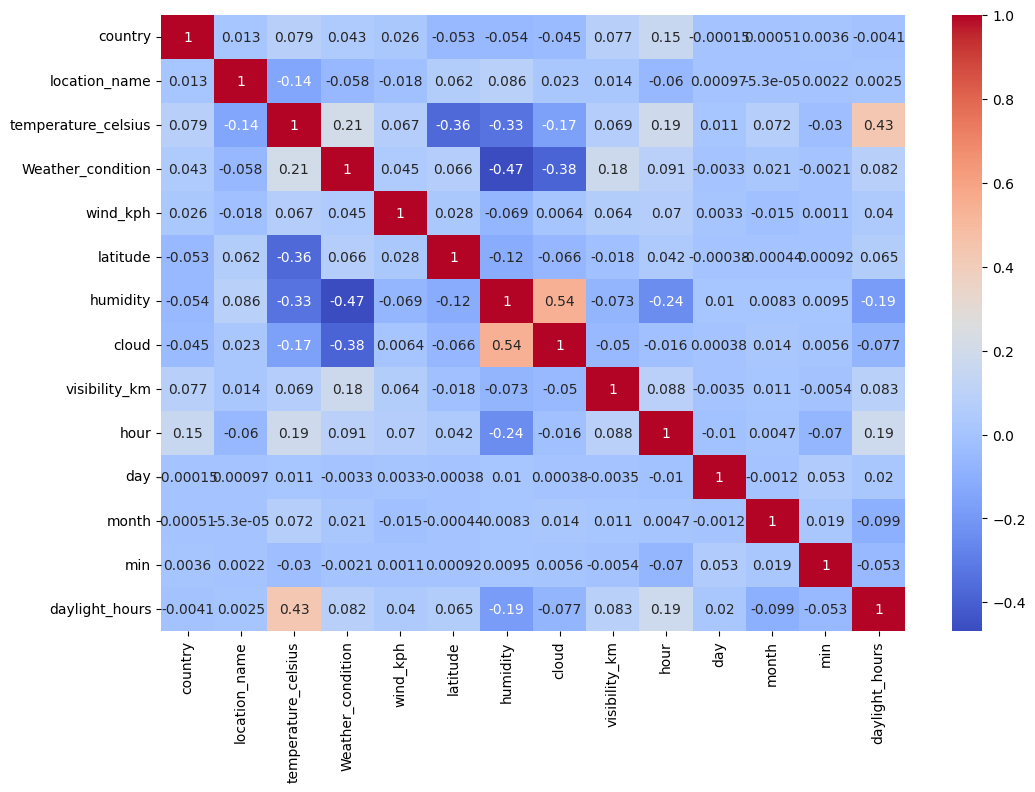

In [14]:
#Visualizing The Data For Finding the Correlation between The Features
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [32]:
col = df6.pop('temperature_celsius')
df6.insert(12, 'temperature_celsius', col)
col1 = df6.pop('Weather_condition')
df6.insert(13, 'Weather_condition', col1)
df7 = df6.copy()

In [ ]:
df7

In [ ]:
#splitting The data into train and test
train, valid, test = np.split(df7.sample(frac=1, random_state = 42), [int(0.6*len(df7)), int(0.8*len(df7))])

In [36]:
#getting ready For training the model
def get_xy(dataframe, y_label, x_label = None):
    if x_label is None or len(x_label) == 0:
        x = dataframe[[c for c in dataframe.columns if c!=y_label]].values.reshape(1, -1)
    else:
        if len(x_label)==1:
            x = dataframe[x_label[0]].values.reshape(-1 ,1)
            
        else:
            x = dataframe[x_label].values
    y = dataframe[y_label].values
    data = np.hstack((x, y))
    return data , x, y

In [37]:


train, x_train, y_train = get_xy(train, ['temperature_celsius', 'Weather_condition'], x_label = df7.columns[:12])
valid, x_valid, y_valid = get_xy(valid, ['temperature_celsius', 'Weather_condition'], x_label = df7.columns[:12])
test, x_test, y_test = get_xy(test, ['temperature_celsius', 'Weather_condition'], x_label = df7.columns[:12])


In [ ]:
y_valid

In [ ]:
col1  = y_train[:, 0]
col2  = y_train[:, 1]
col3 =  y_valid[:, 0]
col4 = y_valid[:, 1]
np.var(col1)

In [40]:
#importing the keras 
import keras 
from keras.layers import Input, Dense, Dropout
from keras.models import Model
from keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint

In [23]:
#Building the ANN Architecture

inputs = Input(shape=(len(df7.columns[:12]),))         #input layer

x = Dense(32, activation="relu")(inputs)               #hidden layer1
x1 = Dense(16, activation="relu")(x)                   #hidden layer2
x2 = Dense(32, activation = "relu")(x1)                #hidden layer 3


temp_output = Dense(1, name="temperature_output")(x1)     #Output layer for temperature

condition_output = Dense(num_classes, activation="softmax", name="condition_output")(x2)     #Output layer for weather condition

model = Model(inputs=inputs, outputs=[temp_output, condition_output])                      #giving the inputs and outputs to the model

model.compile(optimizer = 'Adam', loss = {'temperature_output': 'mse', 'condition_output': 'sparse_categorical_crossentropy'}, #compiling the model or forward propagation
              loss_weights = {'temperature_output': 0.5, 'condition_output': 2.0},
             metrics = {'temperature_output': ['mse'], 'condition_output': ['accuracy']}
            )


In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 12)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │             416 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             528 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │             544 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ temperature_output (Dense)    │ (None, 1)                 │              17 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ condition_output (Dense)      │ (None, 47)                │           1,551 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,056 (11.94 KB)

 Trainable params: 3,056 (11.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",                          #saving the model's best weights
    monitor="val_condition_output_accuracy",               
    save_best_only=True,             
    mode="max", 
    verbose = 0
)

history = model.fit(x_train, {'temperature_output': col1, 'condition_output': col2},
                    validation_data = (x_valid, {'temperature_output': col3, 'condition_output': col4}),        #fitting the model or backpropagation
                    epochs = 20,
                    batch_size = 32,
                    callbacks = [checkpoint]
                   )
                    

In [48]:
#saving the history
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)


In [ ]:
col5 = y_test[:, 0]                           #temperature test data
col6 = y_test[:, 1]                           #weather condition test data

In [167]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)[0]       # temperature output predictions
print("Validation R²:", r2_score(col5, y_pred))

460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step
Validation R²: 0.9899231451874515


In [ ]:
y_cond_pred = model.predict(x_test)[1]
y_pred_cond = np.argmax(y_cond_pred, axis = 1)    #Weather condition output predictions


In [ ]:
print(classification_report(col6, y_pred_cond, zero_division = 0))      #$classification report


In [170]:
model.save('my_model.keras')     #saved the model

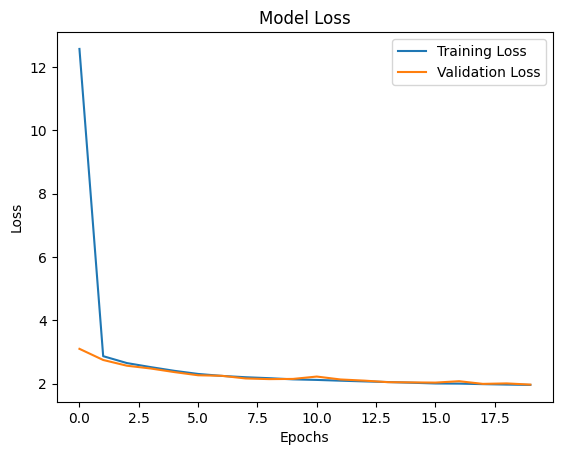

In [44]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

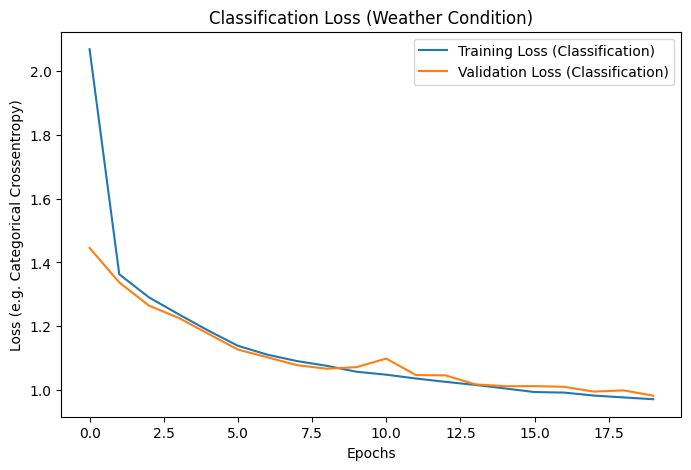

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["condition_output_loss"], label="Training Loss (Classification)")
plt.plot(history.history["val_condition_output_loss"], label="Validation Loss (Classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss (e.g. Categorical Crossentropy)")
plt.title("Classification Loss (Weather Condition)")
plt.legend()
plt.show()

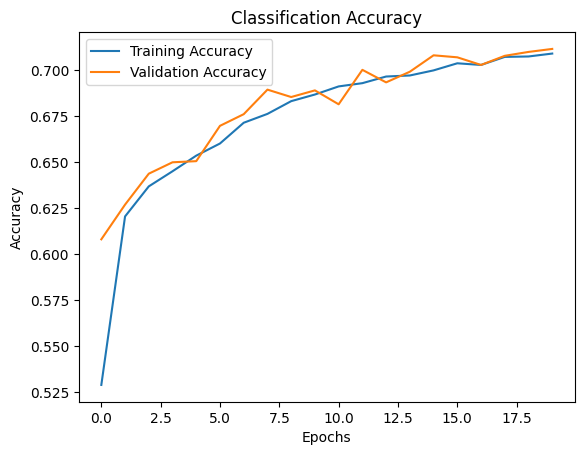

In [45]:

plt.plot(history.history['condition_output_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_condition_output_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy')
plt.legend()
plt.show()

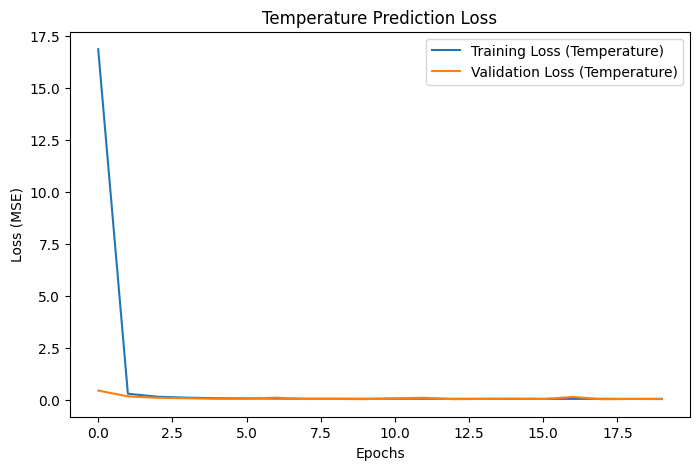

In [47]:


plt.figure(figsize=(8, 5))
plt.plot(history.history["temperature_output_loss"], label="Training Loss (Temperature)")
plt.plot(history.history["val_temperature_output_loss"], label="Validation Loss (Temperature)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Temperature Prediction Loss")
plt.legend()
plt.show()
